## <center>Problem Sheet #6</center>

<img src="zombie.gif" width="700">
<br>
<br>


## <a href="https://en.wikipedia.org/wiki/Multigrid_method">Multigrid method</a>
<br>

### Damped Jacobi iteration
<br>
<b>Problem 1.</b> Let us consider the one dimensional Laplace equation with homogeneous Dirichlet boundary. Make a single plot about Fourier modes for $k=1,3,6$.<br>

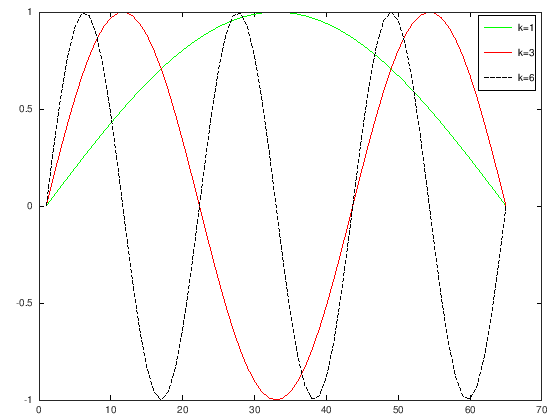

In [3]:
N=64;
x01=zeros(N+1,1);
for j=1:N+1
 x01(j)=sin(1*pi*(j-1)/N);
end
x02=zeros(N+1,1);
for j=1:N+1
 x02(j)=sin(3*pi*(j-1)/N);
end
x03=zeros(N+1,1);
for j=1:N+1
 x03(j)=sin(6*pi*(j-1)/N);
end
index=1:1:N+1;
plot(index,x01','g',index,x02,'r',index,x03','k--')
legend('k=1','k=3','k=6')

<br>
<b>Problem 2.</b> Let us apply to the previous problem the damped Jacobi iteration for $\omega=2/3$, given number of iterations and starting vector $x^{(0)}$.
<br>

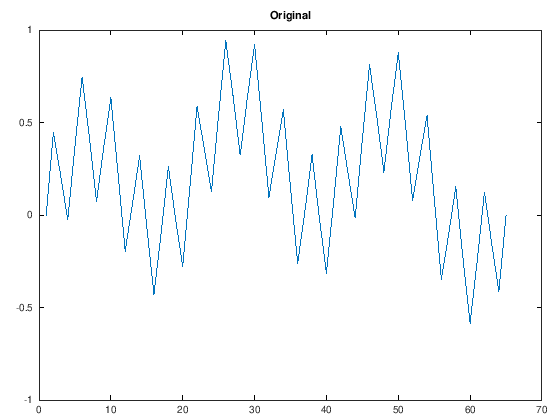

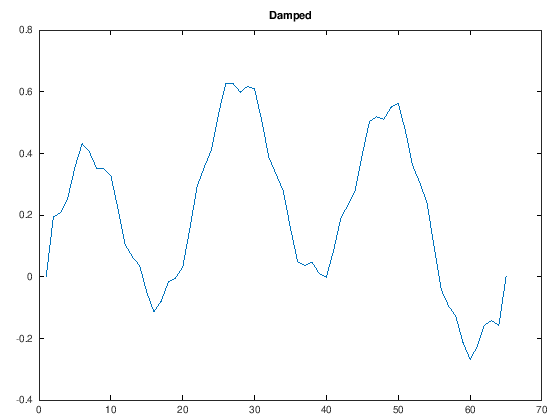

In [2]:
N=64;
x0=zeros(N+1,1);
for j=1:N+1
 x0(j)=1/3*(sin(pi*(j-1)/N)+sin(6*pi*(j-1)/N)+sin(32*pi*(j-1)/N));
end
index=1:1:N+1;
plot(index,x0')
title('Original')
b=zeros(N+1,1);
[x1,itt1] = dampedjacobi(N,b,x0,3);
x1(1)=0;
x1(end)=0;
figure
plot(index,x1)
title('Damped')

<br>
<b>Problem 3.</b> Taking into account the construction of Problem 2. how does the error change in the first 100 iteration steps? Plot our results!
<br>

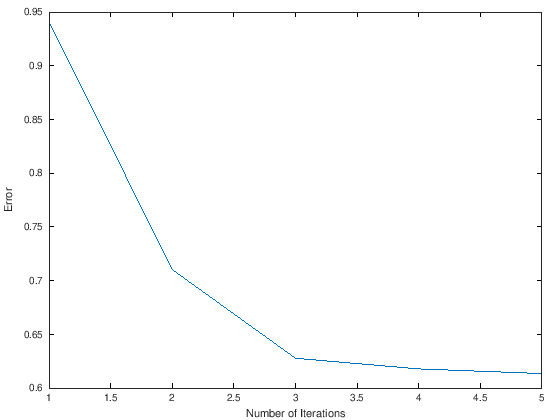

In [3]:
for j=1:5;
    [x1,itt] = dampedjacobi(N,b,x0,j);
    norm_max(j)=norm(x1,'inf');
end
plot(1:1:5,norm_max)
xlabel('Number of Iterations')
ylabel('Error')

### Restriction (Injection or fine-to-coarse) operators
<br>
<b>Problem 4.</b> Write the coarsest restriction operator in 1D and 2D.<br>

In [6]:
% (a) 1D
N=4;
vh=[1:N]';
vH=vh(2:2:N)

vH =

   2
   4



In [7]:
% (b) 2D

N=4;
e=ones(N,1);
%A=spdiags([e -2*e e], [-1 0 1], N, N);
A=spdiags([[1:N]' [1:N:N^2]' [N:-1:1]'],[-2 0 1], N, N);
full(A)
vh=reshape(A',N^2,1);
for i=1:N/2
    for j=1:N/2
        vH(i,j)=A(2*i,2*j);
    end
end
full(vH)

ans =

    1    3    0    0
    0    5    2    0
    1    0    9    1
    0    2    0   13

ans =

    5    0
    2   13



### Prolongation (Interpolation or coarse-to-fine) operators
<br>
<b>Problem 5.</b>  Write the coarsest prolongation operator in 1D and 2D.<br>

In [8]:
% (a) 1D
N=4;
vH=[1:N]';
for i=1:N;
    vh(2*i)=vH(i);
    vh(2*i-1)=vH(i);
end
vh

vh =

Compressed Column Sparse (rows = 16, cols = 1, nnz = 13 [81%])

  (1, 1) ->  1
  (2, 1) ->  1
  (3, 1) ->  2
  (4, 1) ->  2
  (5, 1) ->  3
  (6, 1) ->  3
  (7, 1) ->  4
  (8, 1) ->  4
  (9, 1) ->  1
  (11, 1) ->  9
  (12, 1) ->  1
  (14, 1) ->  2
  (16, 1) ->  13



In [9]:
% (b) 2D
clear all
N=4;
e=ones(N,1);
%A=spdiags([e -2*e e], [-1 0 1], N, N);
A=spdiags([[1:N]' [1:N:N^2]' [N:-1:1]'],[-2 0 1], N, N);
full(A)
vh=reshape(A',N^2,1);
for i=1:N
    for j=1:N
        vH(2*i,2*j)=A(i,j);
        vH(2*i,2*j-1)=A(i,j);
        vH(2*i-1,2*j)=A(i,j);
        vH(2*i-1,2*j-1)=A(i,j);
    end
end
full(vH)


ans =

    1    3    0    0
    0    5    2    0
    1    0    9    1
    0    2    0   13

ans =

    1    1    3    3    0    0    0    0
    1    1    3    3    0    0    0    0
    0    0    5    5    2    2    0    0
    0    0    5    5    2    2    0    0
    1    1    0    0    9    9    1    1
    1    1    0    0    9    9    1    1
    0    0    2    2    0    0   13   13
    0    0    2    2    0    0   13   13

